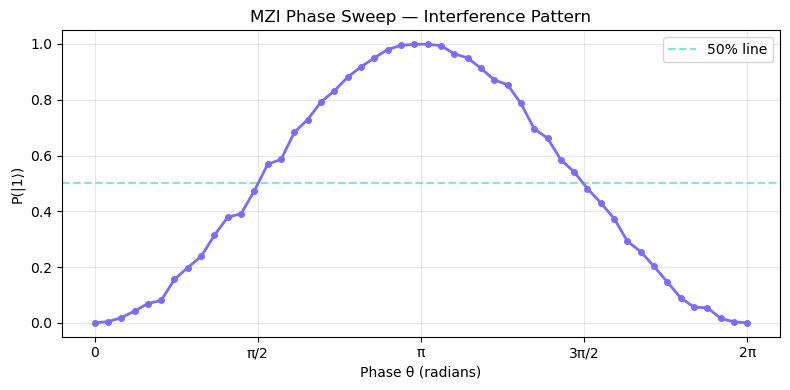

In [3]:
# 02_mzi_phase_sweep.ipynb
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

simulator = AerSimulator()

# Sweep phase from 0 to 2π
angles = np.linspace(0, 2 * np.pi, 50)
p1_values = []

for theta in angles:
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.rz(theta, 0)
    qc.h(0)
    qc.measure(0, 0)
    
    counts = simulator.run(qc, shots=1000).result().get_counts()
    p1 = counts.get('1', 0) / 1000
    p1_values.append(p1)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(angles, p1_values, 'o-', color='#7c6bff', lw=2, markersize=4)
plt.axhline(0.5, color='#00d4aa', linestyle='--', alpha=0.5, label='50% line')
plt.xlabel("Phase θ (radians)")
plt.ylabel("P(|1⟩)")
plt.title("MZI Phase Sweep — Interference Pattern")
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', 'π/2', 'π', '3π/2', '2π'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mzi_phase_sweep.png", dpi=150, bbox_inches='tight')
plt.show()